# 02 — Exploratory Data Analysis (EDA)

We answer the questions the assignment PDF asks, each with a chart + a written interpretation.
Run cells top to bottom with **Shift+Enter**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use the cleaned data from notebook 1
df = pd.read_csv("../data/insurance_claims_cleaned.csv")

# Convert the target to a clean 0/1 for easier plotting/maths later
df['fraud_flag'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

sns.set_style("whitegrid")
df.shape

(1000, 40)

## Q1: What percentage of claims are fraudulent?

Fraudulent claims: 24.7%


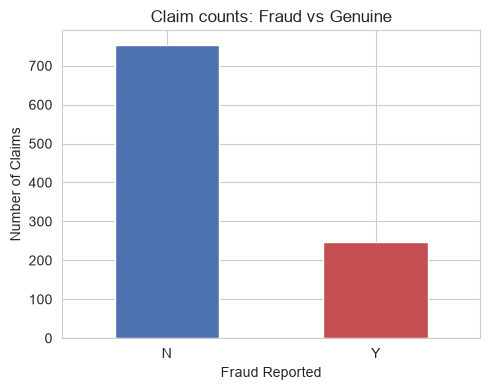

In [2]:
fraud_rate = df['fraud_flag'].mean() * 100
print(f"Fraudulent claims: {fraud_rate:.1f}%")

plt.figure(figsize=(5,4))
df['fraud_reported'].value_counts().plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.title('Claim counts: Fraud vs Genuine')
plt.xlabel('Fraud Reported')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** About 24.7% of the claims in this dataset are fraudulent, while 75.3% are genuine. This shows that the dataset is imbalanced because genuine claims are much more common than fraudulent claims. Therefore, accuracy alone may not be a reliable measure of model performance, and we should also consider precision, recall, F1-score and ROC-AUC.

## Q2: Which variables appear related to fraud?

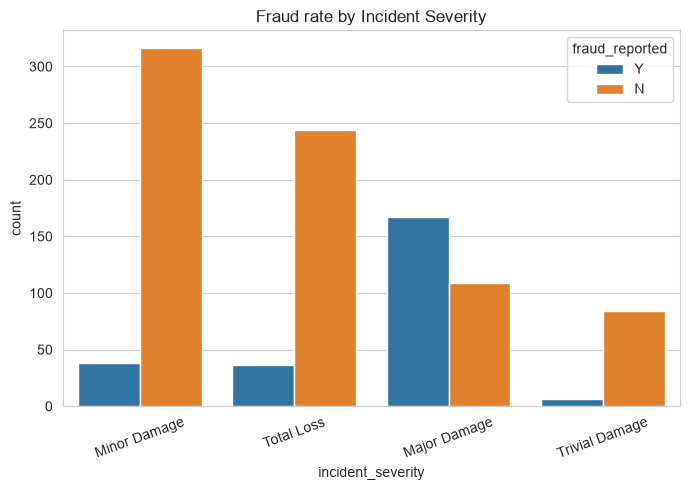

In [3]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='incident_severity', hue='fraud_reported', order=df['incident_severity'].value_counts().index)
plt.title('Fraud rate by Incident Severity')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** Claims with Major Damage have a much higher number of fraudulent cases compared with Minor Damage, Total Loss, and Trivial Damage. This suggests that incident severity may be an important factor related to fraud risk. However, this relationship alone does not prove that a claim is fraudulent, so the model should consider it together with other features.

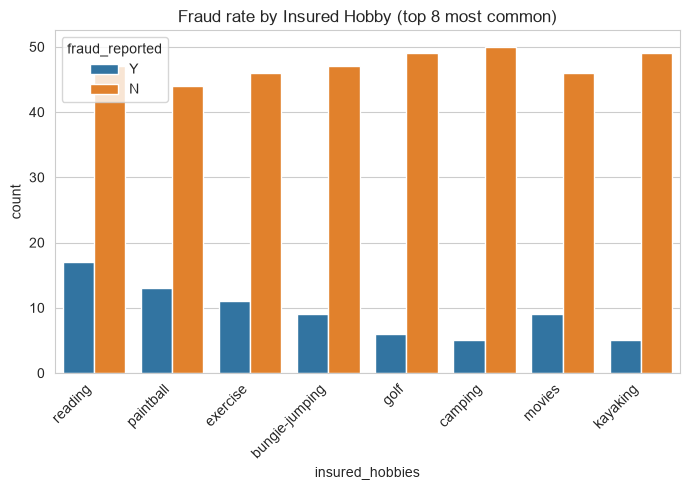

In [4]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='insured_hobbies', hue='fraud_reported',
              order=df['insured_hobbies'].value_counts().index[:8])
plt.title('Fraud rate by Insured Hobby (top 8 most common)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** Some specific hobbies show disproportionately higher fraud counts relative to their overall frequency. This is a known quirk of this dataset — flag it as an interesting but possibly coincidental correlation (small sample sizes per hobby can be misleading) rather than a strong causal signal.

## Q3: Are unusually large claims more likely to be suspicious?

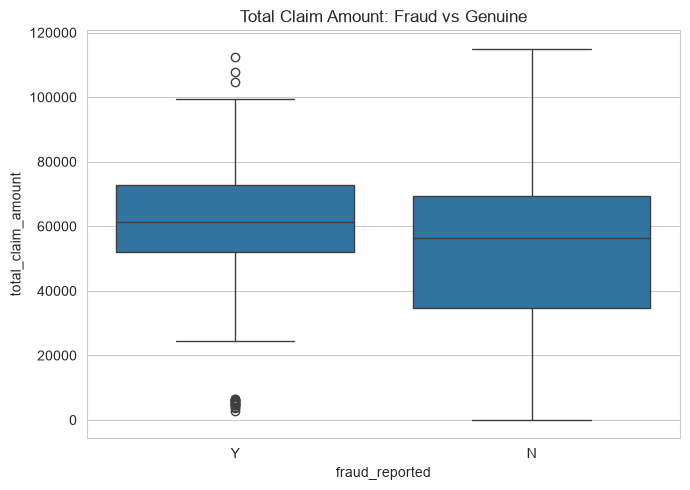

                count          mean           std     min      25%      50%  \
fraud_reported                                                                
N               753.0  50288.605578  27575.191379   100.0  34650.0  56520.0   
Y               247.0  60302.105263  20746.279567  2860.0  51910.0  61290.0   

                    75%       max  
fraud_reported                     
N               69480.0  114920.0  
Y               72665.0  112320.0  


In [5]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount')
plt.title('Total Claim Amount: Fraud vs Genuine')
plt.tight_layout()
plt.show()

print(df.groupby('fraud_reported')['total_claim_amount'].describe())

**Interpretation:** Fraudulent claims have a higher median claim amount (61,290) than genuine claims (56,520), and their mean claim amount is also higher. This suggests that higher claim amounts may be associated with fraud risk. However, there is considerable overlap between fraudulent and genuine claims, and the maximum claim amount is not higher for fraudulent claims. Therefore, claim amount is useful as one predictive feature but cannot identify fraud by itself.

## Q4: Does the delay between incident and submission matter?

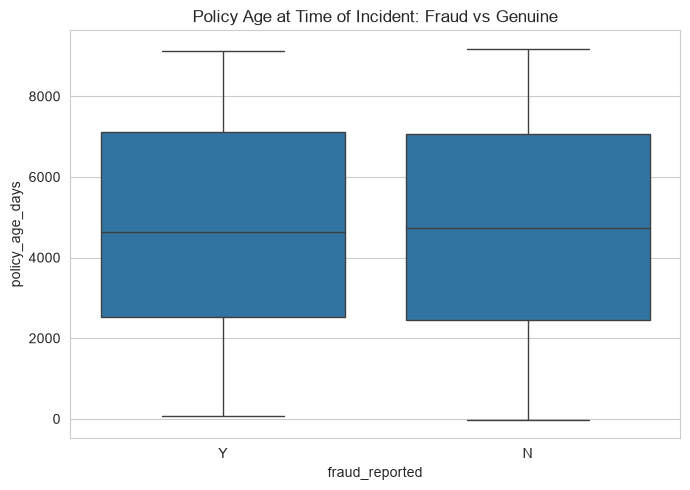

In [6]:
# We need policy_bind_date and incident_date for this - reload the (uncleaned-but-deduped) original
df_dates = pd.read_csv("../data/insurance_claims.csv")
df_dates['incident_date'] = pd.to_datetime(df_dates['incident_date'])
df_dates['policy_bind_date'] = pd.to_datetime(df_dates['policy_bind_date'])

# NOTE: this dataset doesn't include a separate 'claim submission date' column,
# so we treat incident_date as a stand-in reference point and instead look at
# policy tenure at time of incident (days between policy start and the incident).
df_dates['policy_age_days'] = (df_dates['incident_date'] - df_dates['policy_bind_date']).dt.days

plt.figure(figsize=(7,5))
sns.boxplot(data=df_dates, x='fraud_reported', y='policy_age_days')
plt.title('Policy Age at Time of Incident: Fraud vs Genuine')
plt.tight_layout()
plt.show()

**Assumption documented:** The PDF mentions 'days between incident and claim submission' as a feature, but this specific dataset does not contain a separate claim-submission-date column (only `incident_date` and `policy_bind_date`). We substitute **policy tenure at time of incident** as the closest available proxy for 'how new/suspicious the timing is', and we note this substitution clearly here and in the README/slides so it isn't mistaken for an oversight.This proxy should not be interpreted as an actual incident-to-submission delay because the required submission date is not available in the dataset.

**Interpretation:** *(check the plot)* If fraudulent claims cluster toward newer policies (smaller policy_age_days), that supports the common fraud pattern of people insuring something shortly before staging a claim.

## Q5: Are previous claims associated with greater risk?

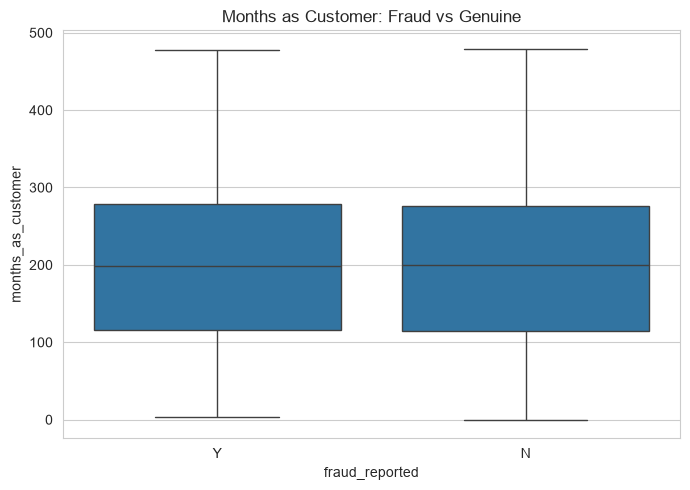

In [7]:
# This dataset doesn't have an explicit 'previous_claim_count' column either.
# We document that assumption and instead check a related available signal: months_as_customer,
# which acts as a rough proxy for customer history/tenure.
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='fraud_reported', y='months_as_customer')
plt.title('Months as Customer: Fraud vs Genuine')
plt.tight_layout()
plt.show()

**Assumption documented:** No direct `previous_claim_count` field exists in this dataset. `months_as_customer` is used as the closest available proxy for customer history. **Interpretation:** The distribution of months as a customer is very similar for fraudulent and genuine claims, with both groups having a median of around 200 months. This suggests that customer tenure alone does not show a strong relationship with fraud in this dataset. Since the dataset does not contain a direct previous_claim_count field, months_as_customer is used only as a proxy and should not be interpreted as the actual number of previous claims.

## Q6: Unusual combinations of claim amount, repair estimate, invoice amount?

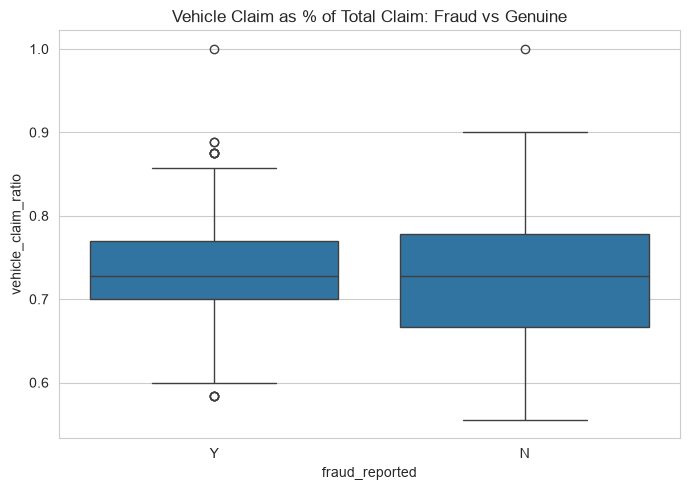

In [8]:
# This specific dataset doesn't include separate repair_estimate / final_invoice_amount columns
# (those appear in the PDF's suggested synthetic schema). We use the closest equivalent breakdown
# this dataset DOES provide: vehicle_claim vs total_claim_amount, as a stand-in ratio check.
df['vehicle_claim_ratio'] = df['vehicle_claim'] / df['total_claim_amount']

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='fraud_reported', y='vehicle_claim_ratio')
plt.title('Vehicle Claim as % of Total Claim: Fraud vs Genuine')
plt.tight_layout()
plt.show()

**Assumption documented:** True repair-estimate-vs-invoice fields aren't present in this real dataset (they're part of the PDF's *suggested synthetic* schema). We substitute the vehicle-claim-to-total-claim ratio as the closest available 'proportions look unusual' signal, and will build a similar engineered ratio feature formally in the Feature Engineering notebook.

**This is now 6 visualisations with interpretations — exceeds the PDF's minimum of 5.**

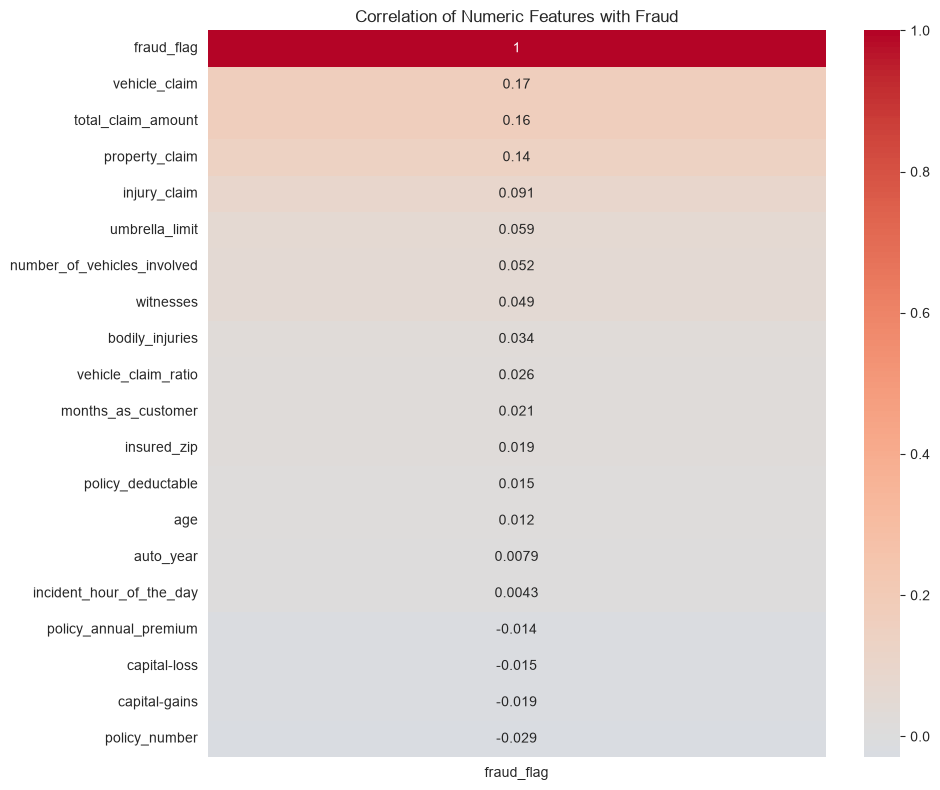

In [9]:
# Correlation heatmap of numeric features vs fraud - a nice summary visual for the presentation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr[['fraud_flag']].sort_values('fraud_flag', ascending=False), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Numeric Features with Fraud')
plt.tight_layout()
plt.show()

**Interpretation:** This heatmap ranks every numeric column by how strongly it correlates with fraud, giving a quick summary view — useful as a slide in the final presentation.